In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("housing.csv")

In [7]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [9]:
df.shape

(20640, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [43]:
##Data cleaning

In [45]:
#check missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [47]:
#fill them
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32120\200431194.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [51]:
#Check duplicates
df.duplicated().sum()

0

In [53]:
#Exploratory Data Analysis (EDA)

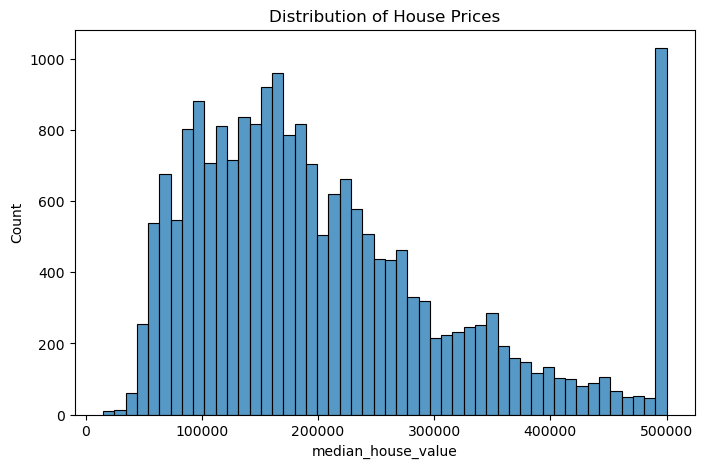

In [55]:
#Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df['median_house_value'], bins=50)
plt.title("Distribution of House Prices")
plt.show()

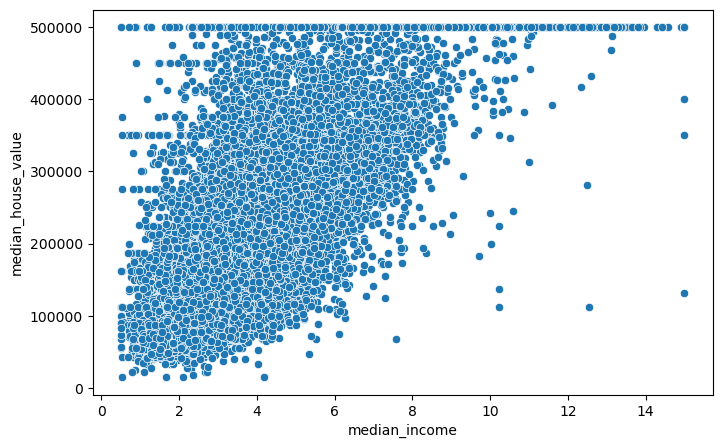

In [57]:
#Income vs House price
plt.figure(figsize=(8,5))
sns.scatterplot(x="median_income", y="median_house_value", data=df)
plt.show()


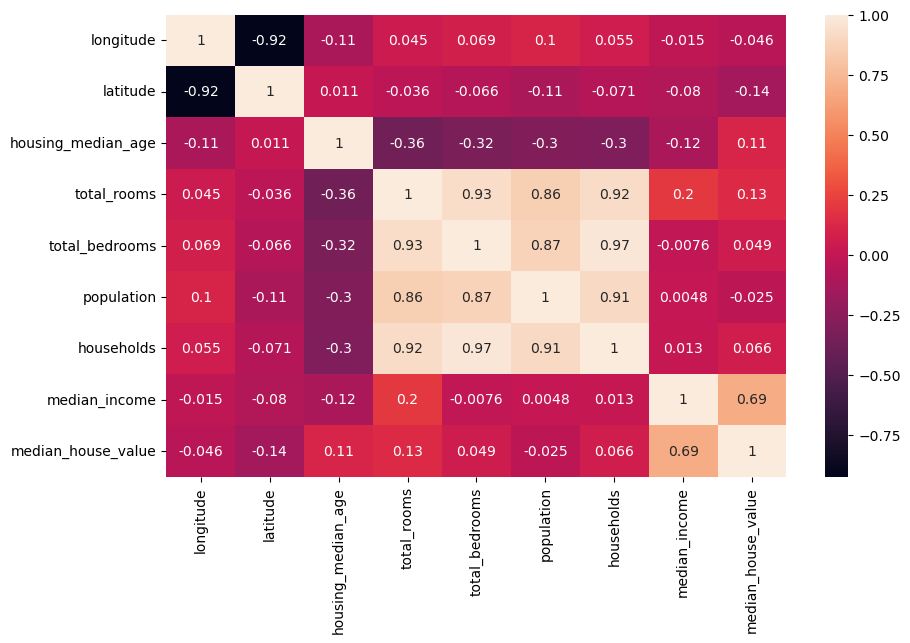

In [59]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

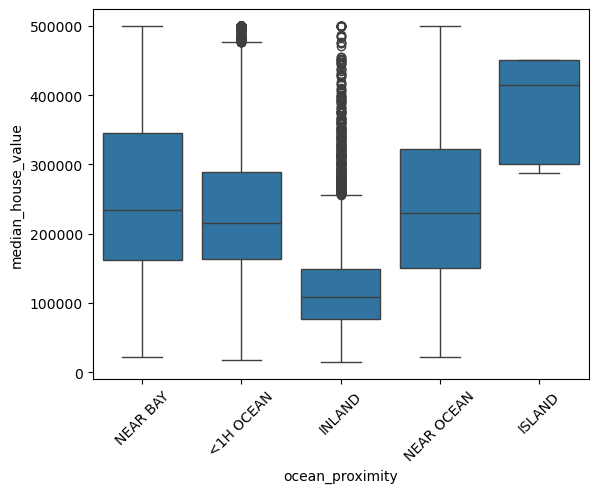

In [61]:
#Ocean Proximity Analysis
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df)
plt.xticks(rotation=45)
plt.show()
#Houses near the ocean tend to have higher prices.

In [63]:
#Fetaure Engineering


In [65]:
#Rooms per household

df["rooms_per_household"] = df["total_rooms"] / df["households"]

In [67]:
#Bedrooms per room

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

In [69]:
#Population per household

df["population_per_household"] = df["population"] / df["households"]

In [73]:
##Encode Categorical Data (col->ocean_proximity)

In [75]:
#Convert to numeric
df = pd.get_dummies(df, columns=["ocean_proximity"])

In [77]:
###Train Machine Learning Model

In [79]:
#Split dataset
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [85]:
#Predict

predictions = model.predict(X_test)

In [87]:
###Model Evaluation

#Check performance:

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print(mae)

50888.66001572004


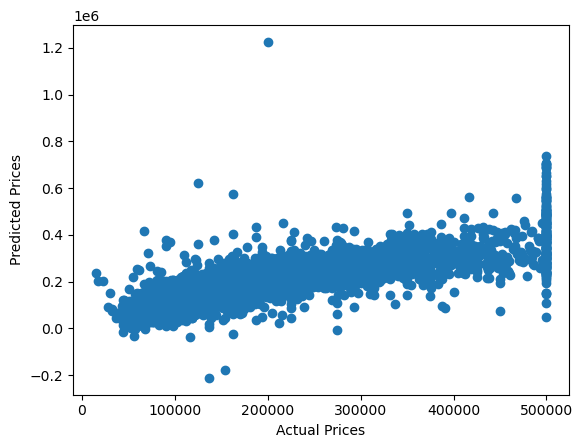

In [89]:
#Visualize Predictions
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

In [91]:
#Save Model
import pickle

pickle.dump(model, open("house_price_model.pkl", "wb"))

In [93]:
####Advanced EDA##

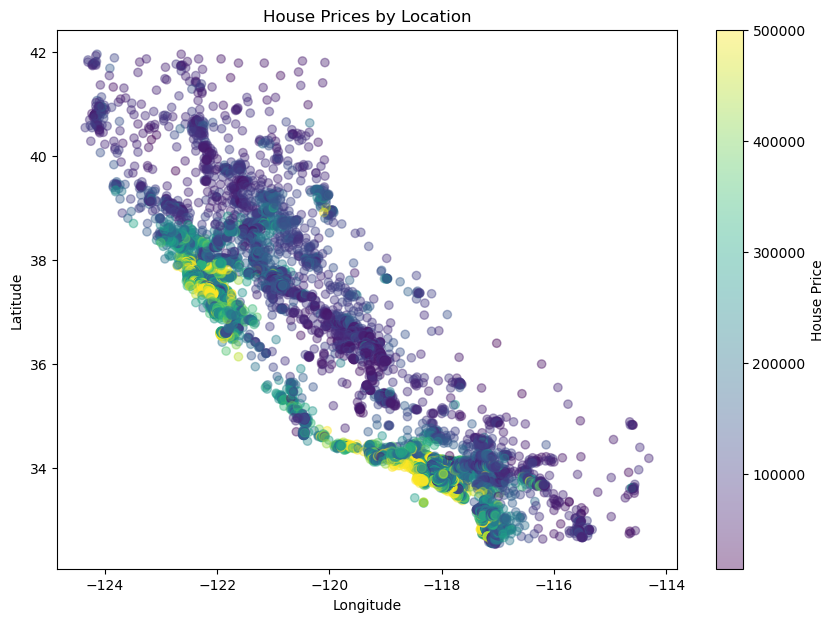

In [97]:
#Location Map Analysis
#Your dataset has latitude and longitude, so we can visualize house prices geographically.
plt.figure(figsize=(10,7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    alpha=0.4
)

plt.colorbar(label="House Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Location")
plt.show()

In [101]:
#Income Category Analysis

#Create income groups.

df["income_category"] = pd.cut(
    df["median_income"],
    bins=[0,2,4,6,8,10],
    labels=["Low","Lower-Mid","Mid","Upper-Mid","High"]
)

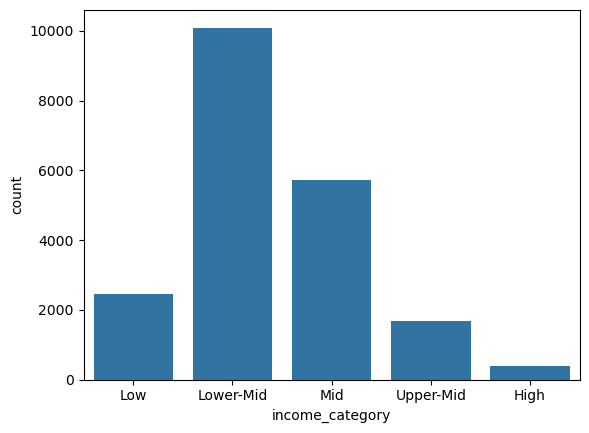

In [103]:
sns.countplot(x="income_category", data=df)
plt.show()

In [105]:
#Feature Correlation with Target
#Find top factors affecting house price.

corr = df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)
print(corr)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population_per_household     -0.023737
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
bedrooms_per_room            -0.233303
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64
